# Regressão Linear

A regressão linear consiste em tentar explicar o comportamento de uma variável, dita *dependente*, a partir de uma ou mais variáveis, ditas *independentes*, com um modelo linear.



## 1. Regressão Linear Simples

A regressão linear simples trata de apenas uma variável independente.

seja $Y = \left\{y_1, y_2, \ldots, y_n\right\}$ uma amostra do conjunto de variáveis independentes e $X = \left\{x_1, x_2, \ldots, x_n\right\}$

O modelo linear para o comportamento destas variáveis é dado pela equação:

\begin{equation}
y_i = w_0 + w_1 x_i + \epsilon_i
\end{equation}

Onde $w_0, w_1$ são *parâmetros* do modelo e $\epsilon_i$ são *resíduos* (a diferença entre o modelo real e os dados realmente observados).

A hipótese do modelo linear é a de que os resíduos são variáveis aleatórias *independentes* distribuídas de acordo com uma distribuição *Gaussiana* de valor esperado *nulo*.

Isso equivale a supor que as variáveis independentes são resultado da reta $y = w_0 + w_1 x$ sobreposta a um ruído Gaussiano.

Adicionando-se a hipótese de que os ruídos Gaussianos são todos com a mesma covariância, os parâmetros da reta de *máxima verissimilhança* são dados por:

\begin{equation}
\underset{w_0, w_1}{\mbox{arg min}} \sum_i \epsilon_i^2= \sum_i \left(y_i - w_0 - w_1 x_i\right)^2
\end{equation}

Definindo-se:

\begin{align}
\bar{x} &= \frac{1}{n}\sum_i x_i \\
\bar{y} &= \frac{1}{n}\sum_i y_i \\
s_{xx} &= \sum_i (x_i - \bar{x})^2 \\
s_{yy} &= \sum_i (y_i - \bar{y})^2 \\
s_{xy} &= \sum_i (x_i - \bar{x})(y_i - \bar{y})
\end{align}

Então tem-se:

\begin{align}
w_1 &= \frac{s_{xy}}{s_{xx}}\\
w_0 &= \bar{y} - w_1 \bar{x}
\end{align}

E finalmente, a soma total dos quadrados dos resíduos é dada por:

\begin{equation}
\sum_i \epsilon_i^2=s_{yy}\left(1-\frac{{s_{xy}}^2}{s_{xx} s_{yy}}\right)
\end{equation}

O valor

\begin{equation}
\frac{s_{xy}}{\sqrt{s_{xx} s_{yy}}}
\end{equation}

é chamado de *coeficiente de correlação de Pearson*. Este é um valor que varia de -1 a 1 e mede o quão bem a variável dependente pode ser explicada por um modelo linear da variável dependente.
Valores mais próximos de zero significam um modelo linear menos explicativo.
Valores mais próximos de 1 ou -1 significam um modelo linar mais explicativo.



### Exercício 1.1:

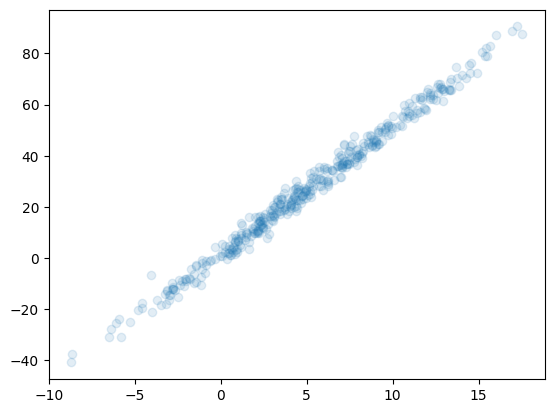

In [117]:
import numpy as np
import matplotlib.pyplot as plt

x = np.random.normal(5, 5, 400)
y = 5*x + 2 + np.random.normal(0, 2.5, 400) 
plt.scatter(x=x, y=y,alpha=0.125)
plt.show()

A variável ```y``` é gerada artificialmente a partir de um modelo linear $y = 5x +2$ sobreposto a um ruído Gaussiano.

Determine:

  a) Os valores de $\bar{x}$, $\bar{y}$

In [ ]:
# Complete com seu código 
# x com uma barra em cima, significa média aritmética.
x_barra = np.mean(x) 
y_barra = np.mean(y)

print("x = ",x_barra)
print("y = ",y_barra)

x =  5.580158413569459
y =  29.817502887255145


b) Os valores de $S_{xx}$, $S_{xy}$, $S_{yy}$

In [ ]:
# Complete com seu código
# Calculo sxx = para cada valor de x subtrair a média de x, elevar ao quadrado e depois somar todos os resultados.
s_xx = np.sum((x - x_barra) ** 2) # dispersão do valores de x em torno da média
# Calculo syy = para cada valor de y subtrair a média de y, elevar ao quadrado e depois somar todos os resultados.
s_yy = np.sum((y - y_barra) ** 2) # dispersão do valores de y em torno da média
# Para cada par(x,y), calcular o desvio em relação as médias, multiplicar os resvios e somar todos os resultados. 
s_xy = np.sum((x - x_barra) * (y - y_barra)) # Mede como x e y variam juntos.

print("Sxx = ",s_xx)
print("Syy = ",s_yy)
print("Sxy = ",s_xy)


Sxx =  8688.95504907359
Syy =  218736.96181993236
Sxy =  43330.92005088443


c) Os valores de  $w_0$ e $w_1$ no modelo $y_i = w_0 + w_1 x_i + \epsilon_i$ de máxima verissimilhança.

In [36]:
# Complete com seu código
# representa a inclinação da reta ajustada aos dados (inclinação)
w_1 = s_xy / s_xx # indica quanto y varia quando o x aumenta uma unidade

# Calcula o ponto onde a reta cruza o eixo Y (intercepto)
w_0 = y_barra - w_1 * x_barra # valor esperado de y quando x=0

print("w0 =", w_0)
print("w1 =", w_1)

w0 = 1.989830086090386
w1 = 4.9868965607670335


d) Repita a plotagem *scatter* do enunciado sobreposta à reta $y=w_0 + w_1 x$

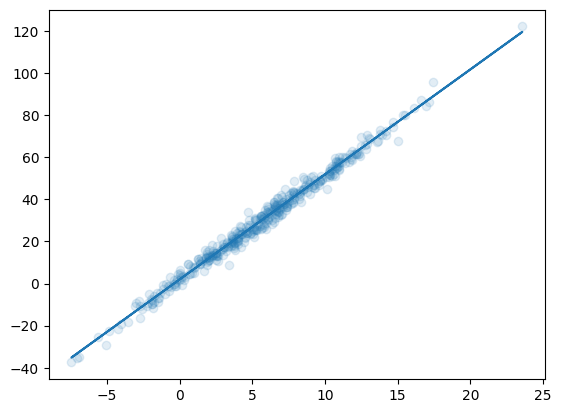

In [37]:
# Complete com seu código
# Cria o gráfico de dispersão dos dados originais
plt.scatter(x, y, alpha=0.124) # alpha controla a transparência dos pontos para facilitar a visualização de regiões com muitos pontos sobrepostos

# Calcula os valores da reta para cada valor de x
y_reta = w_0 + w_1 * x # Para cada valor de x, aplica a equação da reta y = w_0 + w_1*x

# Desenha a reta de regressão sobre os pontos
plt.plot(x, y_reta) # exibe a reta com tamanho inicial de x e final y_reta

plt.show()

e) Calcule o resíduo quadrático total $\sum_i \epsilon_i^2$

In [38]:
# Complete com seu código
# Calcula os valores previstos pelo modelo de regressão
y_pred = w_0 + w_1 * x  # aplica a equação da reta(aprendida) para cada valor de x

# Calcula os resíduos (erros)
erro = y - y_pred  # diferença entre os valores observados e os valores previstos pela reta

# Calcula a soma dos quadrados dos resíduos
residuo_total = np.sum(erro**2)  # eleva cada erro ao quadrado e soma todos os resultados

print("E² =", residuo_total)  # mostra o erro total do modelo de regressão

E² = 2650.1456433055246


f) Calcule o coeficiente de correlação de Pearson
\begin{equation}
r = \frac{s_{xy}}{\sqrt{s_{xx} s_{yy}}}
\end{equation}

Compare o valor $s_{yy}(1-r^2)$ com o obtido no item e).

In [55]:
# Complete com seu código
# Calcula o coeficiente de correlação de Pearson (O Pearson pega a variação conjunta (s_xy) e a normaliza pela dispersão de x e y.)
r = s_xy / np.sqrt(s_xx * s_yy)  # mede a força da relação linear entre x e y

# Calcula s_yy(1-r²)
comparacao = s_yy * (1 - r**2)  # valor teórico do resíduo quadrático total

print("r =", r)
print("s_yy(1-r²) =", comparacao)

r = 0.993923702482203
s_yy(1-r²) = 2650.1456433055455


g) Repita o processo (encontrando os valores de $w_0$, $w_1$, $r$ e a plotagem) usando a biblioteca ```sklearn```
Você deve usar a classe ```LinearRegression``` do pacote ```sklearn.linear_model```.

Crie um objeto da classe ```LinearRegression``` e invoque o método ```fit```, passando como parâmetros ```x.reshape(-1,1)``` (para transformar o vetor em uma matriz coluna) e ```y```.

O valor de $w_0$ pode ser encontrado no atributo ```ìntercept_```.
O valor de $w_1$ pode ser encontrado no primeiro coeficiente do atributo ```coef_```.

O coeficiente de Pearson *ao quadrado* $r²$ pode ser obtido do método ```score``` repassando a ele os mesmos dados passados em ```fit```.
Note que você deve extrair a raiz quadrada deste valor para obter $r$.

Para calcular o vetor de valores previstos, chame o método ```predict``` passando como parâmetro ```x.reshape(-1,1)```.


In [40]:
from sklearn import linear_model

In [ ]:
# Complete com seu código
# Cria uma instância do modelo de regressão linear
modelo = linear_model.LinearRegression()

# Treina o modelo usando os dados x e y
# reshape(-1,1) transforma o vetor x em uma matriz coluna
modelo.fit(x.reshape(-1,1), y)

# Obtém o coeficiente linear (intercepto)
w_0 = modelo.intercept_ 

# Obtém o coeficiente angular (inclinação da reta)
w_1 = modelo.coef_[0]

# Calcula o coeficiente de determinação R²
r2 = modelo.score(x.reshape(-1,1), y)

# Calcula o coeficiente de Pearson
r = np.sqrt(r2)

# Calcula os valores previstos pelo modelo
y_pred = modelo.predict(x.reshape(-1,1))


print("w0 =", w_0)
print("w1 =", w_1)
print("r =", r)


w0 = 1.989830086090386
w1 = 4.9868965607670335
r = 0.993923702482203


### Exercício 1.2

Este [arquivo](https://gitlab.uspdigital.usp.br/thiago/curso-ai-intro-ap/-/raw/main/escolas_turmas_alunos_2017.csv) contém um conjunto compilado de dados da Secretaria Estadual de Educação que trata de alunos do ensino médio em 2017.

A coluna ```CD_ESCOLA``` é um código interno da Secretaria que identifica uma Escola.

A coluna ```APR_3``` contém a taxa de aprovação no ensino médio por escola.

A coluna ```QTDE_ALUNOS``` contém o total de alunos matriculados no ensino médio por escola.

A coluna ```TURMAS``` contém a quantidade total de turmas de ensino médio.

O código a seguir importa os dados em uma base de dados Pandas de nome ```aprovacao_e_alunos_por_escola``` e computa uma nova coluna, ```MEDIA_POR_TURMA```, com o número médio de alunos por turma por escola.

Note que a quantidade de turmas varia significativamente de escola para escola.

,CD_ESCOLA,APR_3,QTDE_ALUNOS,TURMAS,MEDIA_POR_TURMA
0,21623,99.42,172,6,28.666667
1,21726,99.71,345,10,34.500000
2,21748,100.00,239,7,34.142857
3,41661,98.76,161,6,26.833333
4,49967,75.92,259,9,28.777778
...,...,...,...,...,...
3702,48461,89.52,120,4,30.000000
3703,49517,69.68,444,15,29.600000
3704,909524,75.24,259,10,25.900000
3705,914927,85.12,204,7,29.142857


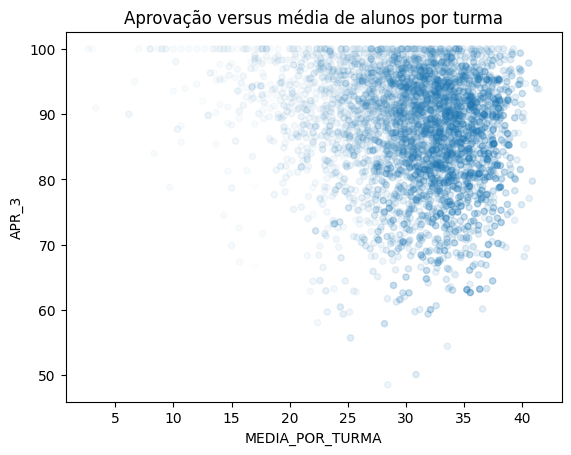

In [45]:
import urllib.request as request
import io
import pandas as pd
aprovacao_e_alunos_por_escola=pd.read_csv(io.TextIOWrapper(request.urlopen("https://gitlab.uspdigital.usp.br/thiago/curso-ai-intro-ap/-/raw/main/escolas_turmas_alunos_2017.csv"), "utf-8-sig"))
aprovacao_e_alunos_por_escola['MEDIA_POR_TURMA'] = aprovacao_e_alunos_por_escola['QTDE_ALUNOS']/aprovacao_e_alunos_por_escola['TURMAS']
max_turmas = aprovacao_e_alunos_por_escola['TURMAS'].max()

opacidade = np.array(aprovacao_e_alunos_por_escola['TURMAS'])/(2*max_turmas)
aprovacao_e_alunos_por_escola.plot.scatter(x="MEDIA_POR_TURMA", y="APR_3", title="Aprovação versus média de alunos por turma", alpha =opacidade)
display(aprovacao_e_alunos_por_escola)
plt.show()

Deseja-se investigar uma possível relação linear entre a média de alunos por turma e a taxa de aprovação.

Para tanto determine:

a) Os coeficientes $w_0$ e $w_1$ de um modelo linear de aprovação em função do total de alunos matriculados.
Como mencionado, a quantidade de turmas varia significativamente de escola para escola.
Isso significa que o *peso* de cada ponto é diferente!
Você deve usar a quantidade de turmas como peso para fazer esta regressão.

#### *Sugestão*:
Use novamente a classe ```LinearModel```.
O método ```fit``` tem um terceiro parâmetro que recebe um vetor com os pesos relativos para cada amostra.

In [68]:
# Complete com seu código
# Quantidade total de alunos matriculados
x = aprovacao_e_alunos_por_escola['QTDE_ALUNOS'].to_numpy()
# Taxa de aprovação
y = aprovacao_e_alunos_por_escola['APR_3'].to_numpy()
# Quantidade de turmas utilizada como peso de cada escola
pesos = aprovacao_e_alunos_por_escola['TURMAS'].to_numpy()

b) O coeficiente de correlação de Pearson $r$ e seu valor ao quadrado $r^2$



In [63]:
# Complete com seu código
# coeficiente de determinação R²
modelo.fit(x.reshape(-1,1), y) # É importante treinar o modelo antes.
r2 = modelo.score(x.reshape(-1,1), y,sample_weight=pesos)  # mede quanto da variação de y é explicada pelo modelo

# coeficiente de correlação de Pearson
r = np.sqrt(r2)  # raiz quadrada de R²

# Exibe os resultados
print("r =", r)
print("r² =", r2)

r = 0.23547814416066692
r² = 0.05544995637735184


c) O gráfico do enunciado sobreposto à reta determinada no item a).

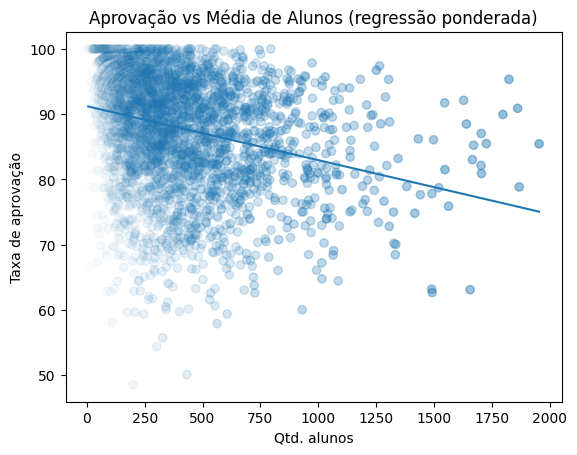

In [71]:
# Complete com seu código
x_reshaped = x.reshape(-1,1) # Garante formato correto para previsão. Muda o formado da dimensao do dado.
y_pred = modelo.predict(x_reshaped) # Calcula os valores previstos pelo modelo treinado. valores da reta ajustada

plt.scatter(x, y, alpha=pesos / (2 * pesos.max())) # Cria o gráfico de dispersão original.
idx = np.argsort(x) # Ordena os valores de x para desenhar a reta corretamente

# Plota a reta ajustada pelo modelo
plt.plot(x[idx], y_pred[idx])

# Títulos do gráfico
plt.title("Aprovação vs Média de Alunos (regressão ponderada)")
plt.xlabel("Qtd. alunos")
plt.ylabel("Taxa de aprovação")

# Exibe o gráfico
plt.show()

## 2. Regressão multi-Linear

A regressão multi-linear trata da relação de uma variável dependente com *múltiplas* variáveis independentes.


seja

\begin{equation}
Y = \begin{bmatrix}y_1\\
y_2\\
\vdots\\
y_n\end{bmatrix}
\end{equation}

 um vetor com uma amostra do conjunto de variáveis independentes e

\begin{equation}
X = \begin{bmatrix}x_{1,1} & x_{1,2} & \ldots & x_{1,m} & 1\\
x_{2,1} & x_{2,2} & \ldots & x_{2,m} & 1\\
 \vdots & \vdots & \ddots & \vdots & \vdots\\
x_{n,1} & x_{n,2} & \ldots & x_{n,m} & 1\end{bmatrix}
\end{equation}

uma matriz $n \times (m+1)$ cujas primeiras $m$ colunas são compostas por uma amostra de cada uma das $m$ variáveis independetes e a sua *última* coluna é composta da constante 1.

O modelo linear para o comportamento destas variáveis é dado pela equação:

\begin{equation}
Y =  X W + E
\end{equation}

Onde:

\begin{equation}
W = \begin{bmatrix}w_1\\
w_2\\
\vdots\\
w_m\\
w_0
\end{bmatrix}
\end{equation}

é o vetor  de $(m+1)$ componentes dos coeficientes de cada uma das variáveis
independentes.
Note que nesta notação o coeficiente $w_0$ é o *último* coeficiente (há notações distintas nas quais ele é o primeiro).

$E$ é o vetor de *resíduos* (a diferença entre o modelo real e os dados realmente observados).

Seguindo a mesma hipótese de que os resíduos são variáveis aleatórias *independentes* distribuídas de acordo com uma distribuição *Gaussiana* de valor esperado *nulo*, o vetor $W$ de *máxima verissimilhança* é dado por:

\begin{equation}
\underset{W}{\mbox{arg min}}  \|E\|^2= \|Y-XW\|^2
\end{equation}

Se $W^*$ é ótimo deste problema, então vale

\begin{equation}
\left(X^T X\right)W^*=X^TY
\end{equation}

A solução deste sistema linear pode ser escrita como:
\begin{equation}
W^*=\left(X^T X\right)^{-1}X^TY
\end{equation}

e a matriz $\left(X^T X\right)^{-1}X$ é dita a *pseudo-inversa* de $X$.

*Nota*: Em geral não é eficiente calcular explicitamente esta matriz.

### Exercício 2.1

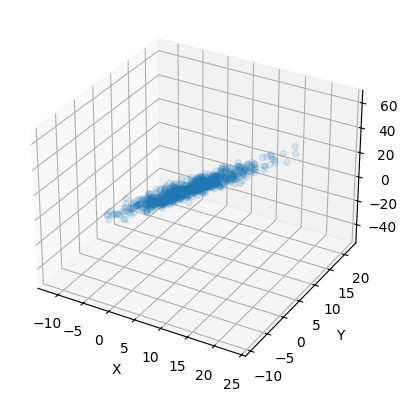

In [133]:
x = np.random.normal(5, 5, 800)
y = np.random.normal(5, 5, 800)
z = 3*x + -2* y + 5 + np.random.normal(0,1,800)
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(x,y,z, alpha=0.125)
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
plt.show()

A variável ```z``` acima é gerada através de um modelo linear $3x - 2y + 5$ sobreposto a um ruído Gaussiano.

a) Calcule através do método acima os coeficientes $w_1, w_2, w_0$ do modelo $z=w_1 x + w_2 y + w_0$ que melhor ajusta o cojunto de pontos das variáveis ```x```, ```y``` e ```z```.

*Nota*: Use a função ```np.linalg.solve(a, b)``` para resolver o sistema $ax=b$.

In [134]:
# Complete com seu código
X = np.column_stack((x, y, np.ones(len(x)))) # cada linha: [x_i, y_i, 1] - empilha vetores como coluna dentro de uma matriz. Vira matriz.

A = X.T @ X # T é atributo da matriz 'trasposto' (linhas por colunas). Multiplicação da matriz transposta de X pela própria X.
b = X.T @ z # T é atributo da matriz 'trasposto'. Multiplicação da matriz transposta de X pelo verto de z.

# Resolve o sistema A W = b
w = np.linalg.solve(A, b)

#  Extrai os coeficientes
w1 = w[0]
w2 = w[1]
w0 = w[2]

print("w1 =", w1)
print("w2 =", w2)
print("w0 =", w0)

w1 = 2.9934016161392405
w2 = -2.0015817358944927
w0 = 5.046955932505598


b) Repita a plotagem 3d do enunciado adicionando o plano que descreve a solução do item a).

*Sugestão*

Se as variáveis ```w_0```, ```w_1``` e ```w_2``` contém respectivamente os valores dos parâmetros $w_0$, $w_0$ e $w_2$, então o código abaixo adiciona o plano solicitado:

```
XX, YY = np.meshgrid(np.linspace(min(x),max(x),2),np.linspace(min(y),max(y),2))
ZZ = w0 + w1*XX + w2*YY
ax.plot_surface(XX, YY, ZZ, color='r', alpha=0.5)
```

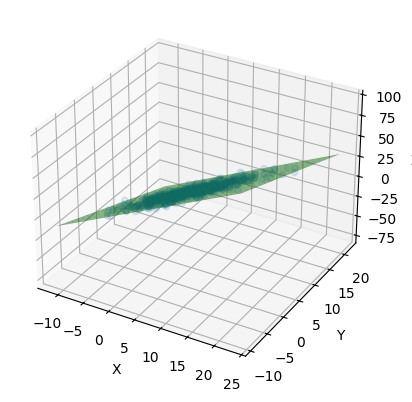

In [ ]:
# Complete com seu código
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# pontos originais
ax.scatter(x, y, z, alpha=0.125)

# grade do plano
XX, YY = np.meshgrid(
    np.linspace(min(x), max(x), 20),
    np.linspace(min(y), max(y), 20))

# plano da regressão
ZZ = w0 + w1 * XX + w2 * YY

# superfície do plano
ax.plot_surface(XX, YY, ZZ, color='g', alpha=0.5)

# rótulos
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

plt.show()

c) Encontre os coeficientes usando a classe ```linear_model.LinearRegression``` do pacote```sklearn```.
Para montar o vetor de variáveis independentes, monte uma matriz com ```np.array([x,y]).T```.
O vetor de variáveis dependentes é o próprio vetor ```z```.

In [ ]:
# Complete com seu código

X = np.array([x, y]).T 

modelo.fit(X, z)

# Coeficientes
w1 = modelo.coef_[0] # coef_ atributo do objeto e o numero é a posição do elemento.
w2 = modelo.coef_[1]
w0 = modelo.intercept_

print("w1 =", w1)
print("w2 =", w2)
print("w0 =", w0)

w1 = 2.9934016161392374
w2 = -2.001581735894488
w0 = 5.0469559325055755


### Exercício 2.2 - Prevendo fenômenos periódicos

O seguinte [arquivo](https://gitlab.uspdigital.usp.br/thiago/curso-ai-intro-ap/-/raw/main/INMET_SE_SP_A705_BAURU.zip) contém dados do Instituto Nacional de Meterologia sobre precipitação na estação A705 em Bauru, desde 2001.

O código a seguir recupera o arquivo e extrai seu conteúdo na pasta ```inmet_bauru```.

In [149]:
!wget https://gitlab.uspdigital.usp.br/thiago/curso-ai-intro-ap/-/raw/main/INMET_SE_SP_A705_BAURU.zip -O inmet_bauru.zip
!unzip -o inmet_bauru.zip -d inmet_bauru

'wget' is not recognized as an internal or external command,
operable program or batch file.


'unzip' is not recognized as an internal or external command,
operable program or batch file.


In [156]:
import urllib.request
import zipfile

url = "https://gitlab.uspdigital.usp.br/thiago/curso-ai-intro-ap/-/raw/main/INMET_SE_SP_A705_BAURU.zip"

urllib.request.urlretrieve(url, "inmet.zip")

with zipfile.ZipFile("inmet.zip", "r") as zip_ref:
    zip_ref.extractall("inmet_bauru")

Podemos usar o leitor de csv do Python para processar estes arquivos.
Note alguns aspectos:
 * As entradas estão organizadas por *horas*.
 * O campo ```PRECIPITAÇÃO TOTAL, HORÁRIO (mm)``` contém a precipitação total em milímetros que caiu durante uma hora.
 * Há uma inconsistência nos campos de data e horas.
 Alguns arquivos usam o campo ```DATA (YYYY-MM-DD)```, outros usam o campo ```Data``` para designar a data.
 Do mesmo modo, alguns usam o campo ```HORA (UTC)```, outros usam o campo ```Hora (UTC)```.
 Em ambos os casos, usa-se o fuso UTC.
 * Nem todo horário possui dados. Há uma nova inconsistência aqui.
 Alguns arquivos usam o valor -9999 para indicar uma entrada sem dados.
 Outros deixam esta entrada em vazio.

 O código abaixo cuida do processamento destes dados, usando a clase ```datetime```.

 Ele produz as seguintes variáveis:

 * ```data_inicial```. Um objeto ```datetime``` que marca um momento de referência (aqui, arbitrariamente definido como as zero horas do dia 1/1/2001.

 * ```datas```. Um vetor com objetos ```datetime``` que contém *todas* as horas contempladas pelo arquivo, inclusive as que não têm dados válidos de precipitação.

  * ```datas_validas```. Um vetor com objetos ```datetime``` que contém *todas* as horas que contém dados válidos de precipitação.

 *```horas_validas```. Um vetor de inteiros correspondentes às horas que contém dados de precipitação. As horas são definidas como a quantidade de horas passadas entre o momento em que elas ocorreram e  ```data_inicial```.

 *```preps```. Um vetor de floats com os dados de precipitação em mm correspondentes às ```datas_validas```.

In [165]:
import csv
import datetime
import pathlib

# Data referência: 0 horas do dia 1/1/2001
data_inicial =  datetime.datetime.strptime("00:00 2001-01-01", "%H:%M %Y-%m-%d").replace(tzinfo=datetime.timezone.utc)

horas_validas = []
datas_validas = []
preps = []
datas = []
dados_presentes = []
arquivos = sorted(pathlib.Path("inmet_bauru").glob("INMET_SE_SP_A705_BAURU_*_A_31-12-*.CSV"), key=lambda path:path.name[-8:-4])
for f in arquivos:
    print(f)
    with open(f, encoding="iso-8859-1") as arquivo:
        # Pula 8 linhas
        for i in range(8):
            arquivo.readline()
        dr = csv.DictReader(arquivo, delimiter=";")
        campo_data = 'DATA (YYYY-MM-DD)'
        if campo_data not in dr.fieldnames:
            campo_data = 'Data'
        campo_hora = 'HORA (UTC)'
        if campo_hora not in dr.fieldnames:
            campo_hora = 'Hora UTC'
        for row in dr:
            dados_validos = 0
            try:
                data = datetime.datetime.strptime(row[campo_data] + " " + row[campo_hora], "%Y-%m-%d %H:%M").replace(tzinfo=datetime.timezone.utc)
            except ValueError:
                data = datetime.datetime.strptime(row[campo_data] + " " + row[campo_hora], "%Y/%m/%d %H%M %Z").replace(tzinfo=datetime.timezone.utc)
            datas.append(data)
            delta = data - data_inicial
            try:
                prep = float(row['PRECIPITAÇÃO TOTAL, HORÁRIO (mm)'].replace(",","."))
                if prep>=0:
                    datas_validas.append(data)
                    horas_validas.append(int(24*delta.days + delta.seconds/3600))
                    preps.append(prep)
                    dados_validos = 1
            except ValueError:
                pass
            dados_presentes.append(dados_validos)
datas_validas = np.array(datas_validas)
horas_validas = np.array(horas_validas)
preps = np.array(preps)
dados_presentes = np.array(dados_presentes)

inmet_bauru\INMET_SE_SP_A705_BAURU_30-08-2001_A_31-12-2001.CSV
inmet_bauru\INMET_SE_SP_A705_BAURU_01-01-2002_A_31-12-2002.CSV
inmet_bauru\INMET_SE_SP_A705_BAURU_01-01-2003_A_31-12-2003.CSV
inmet_bauru\INMET_SE_SP_A705_BAURU_01-01-2004_A_31-12-2004.CSV
inmet_bauru\INMET_SE_SP_A705_BAURU_01-01-2005_A_31-12-2005.CSV
inmet_bauru\INMET_SE_SP_A705_BAURU_01-01-2006_A_31-12-2006.CSV
inmet_bauru\INMET_SE_SP_A705_BAURU_01-01-2007_A_31-12-2007.CSV
inmet_bauru\INMET_SE_SP_A705_BAURU_01-01-2008_A_31-12-2008.CSV
inmet_bauru\INMET_SE_SP_A705_BAURU_01-01-2009_A_31-12-2009.CSV
inmet_bauru\INMET_SE_SP_A705_BAURU_01-01-2010_A_31-12-2010.CSV
inmet_bauru\INMET_SE_SP_A705_BAURU_01-01-2011_A_31-12-2011.CSV
inmet_bauru\INMET_SE_SP_A705_BAURU_01-01-2012_A_31-12-2012.CSV
inmet_bauru\INMET_SE_SP_A705_BAURU_01-01-2013_A_31-12-2013.CSV
inmet_bauru\INMET_SE_SP_A705_BAURU_01-01-2014_A_31-12-2014.CSV
inmet_bauru\INMET_SE_SP_A705_BAURU_01-01-2015_A_31-12-2015.CSV
inmet_bauru\INMET_SE_SP_A705_BAURU_01-01-2016_A_31-12-2

Observa-se que há muitos dados faltantes.
A plotagem a seguir indica os momentos para os quais há dados.
Note em particular a grande lacuna no início de 2004.

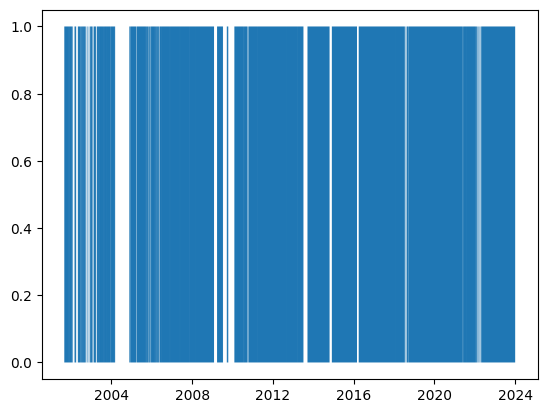

In [158]:
plt.fill_between(datas,dados_presentes,0)

Podemos visualizar os dados de precipitação:

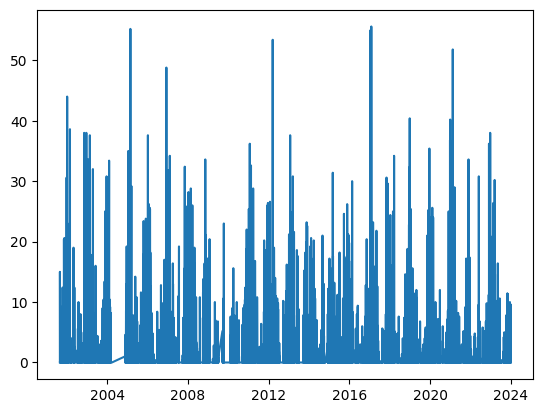

In [166]:
plt.plot(datas_validas,preps)

Apesar de todo o ruído, observa-se no gráfico um fenômeno semi-periódico, que parece se repetir todo ano.
Isso é natural, dada a forte influência das estações do ano no regime pluviométrico.

Podemos identificar as componentes periódicas de uma série temporal usando uma regressão multi-linear com séries harmônicas.

De fato, se uma variável $y(t)$ possui uma componente periódica de período $T$, podemos aproximá-la pela série:

$\bar{y} + \sum_{i=1}^n s_i \sin(2\pi it/T) + c_i \cos(2\pi it/T)$

onde $\bar{y}$ é o valor médio da variável e $s_i$ e $c_i$, com $i$ de $1$ até $n$, são os coeficientes das funções seno e cosseno em diferentes subharmônicas do período principal $T$.

Estes coeficientes, mesmo em cenários de dados incompletos, podem ser obtidos por regressão multilinear.

Vamos fazê-lo para os dados de precipitação com 6 harmônicos.

Para tanto,

a) Monte a matriz de variáveis explicativas:

Considere que um ano *solar* tem aproximadamente 365 dias e 6 horas, ou seja, 8766 horas.
Este será o período base.

Vamos criar duas matrizes, a matriz ```senos``` com os senos e a matriz ```cossenos``` com os cossenos.

A matriz dos senos deve ter 6 colunas. Na sua $j$-ésima coluna os senos do vetor ```horas_validas``` multiplicado por $j+1$ (ou seja, começando em 1 e terminando em 6) e multipliado por $2\pi/8766$.

A matriz dos cossenos deve ser equivalente, mas com a função cosseno.

Monte a matriz completa de variáveis explicativas ```senos_cossenos```  com o comando  ```senos_cossenos = np.concat([senos, cossenos], axis=1)```

Verifique que a matriz ```senos_cossenos``` tem 12 colunas e tantas linhas quanto as entradas no vetor ```preps```.


In [167]:
# Complete com seu código
T = 8766  # horas em um ano - período base

# Matriz de senos
senos = np.column_stack([np.sin((2 * np.pi * (i + 1) * horas_validas) / T) for i in range(6)])

# Matriz de cossenos
cossenos = np.column_stack([np.cos((2 * np.pi * (i + 1) * horas_validas) / T) for i in range(6)])


senos_cossenos = np.concatenate([senos, cossenos], axis=1) # result

print(senos_cossenos.shape)

(173176, 12)


b) Usando a classe ```LinearRegression```, faça a regressão linear do vetor ```preps``` usando esta variável explicativa.

Mostre o comportamento anualizado.
Para isso, monte um vetor explicativo que abrange apenas o período de um ano (repetindo o processo do item a), mas agora, no lugar de ```horas_validas```, use ```np.arange(0,8766)```.
`
Usando o método ```predict```do seu modelo, crie um vetor de precipitação prevista.
Note que este vetor tem 8766 entradas, uma para cada hora de um ano.

Plote este vetor com o método ```plt.plot```.
Determine o momento de máxima precipitação.

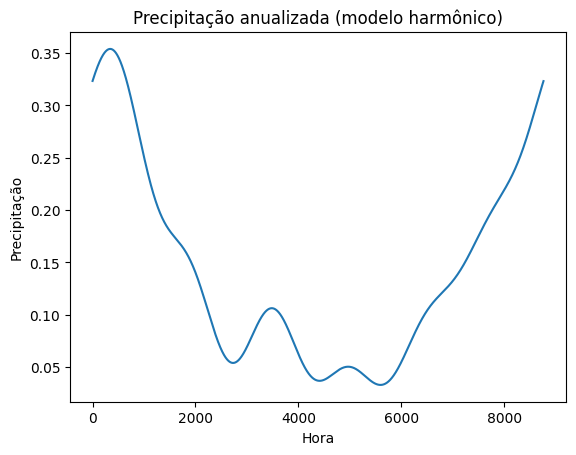

Hora de máxima precipitação: 343
Valor máximo: 0.35390663521156146


In [ ]:
# Complete com seu código
t = np.arange(0, 8766) #

senos = np.column_stack([np.sin((2 * np.pi * (i + 1) * t) / T) for i in range(6)])
cossenos = np.column_stack([np.cos((2 * np.pi * (i + 1) * t) / T) for i in range(6)])

X = np.concatenate([senos, cossenos], axis=1)

modelo = linear_model.LinearRegression()
modelo.fit(senos_cossenos, preps)
preps_pred = modelo.predict(X)

plt.plot(preps_pred)
plt.title("Precipitação anualizada (modelo harmônico)")
plt.xlabel("Hora")
plt.ylabel("Precipitação")
plt.show()

max_index = np.argmax(preps_pred)

print("Hora de máxima precipitação:", max_index)
print("Valor máximo:", preps_pred[max_index])

c) A precipitação real é um fenômeno abrupto, que se manifesta intensamente por algumas poucas horas e cessa na maior parte do dia.
Assim é muito difícil compará-lo com uma linha de tendência que abrange um ano inteiro como no item anterior.

Podemos no entanto comparar a precipitação *acumulada* no ano.
O ano de 2020 é de particular interesse para esta comparação por que não tem lacunas.

O código abaixo usa o método ```cumsum()```, de soma cumulativa de um vetor, para obter a precipitação acumulada em 2020 na variável ```precipitacao_acumulada_2020```:

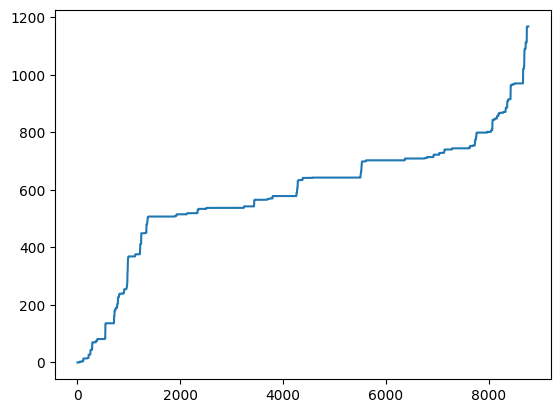

In [173]:
data_inicio_acumulado = datetime.datetime.strptime("00:00 2020-01-01", "%H:%M %Y-%m-%d").replace(tzinfo=datetime.timezone.utc)
delta = data_inicio_acumulado - data_inicial
hora_inicio_acumulado = int(24*(delta.days) + (delta.seconds)/3600)
indice_inicial = np.where(np.array(horas_validas)==hora_inicio_acumulado)[0][0]
precipitacao_acumulada_2020 = preps[indice_inicial:indice_inicial+8766].cumsum()
plt.plot(precipitacao_acumulada_2020)


Use o método ```cumsum()``` no vetor de precipitação previsto obtido no ítem b) e repita a plotagem anterior, sobrepondo-a agora ao vetor de precipitação acumulada prevista.

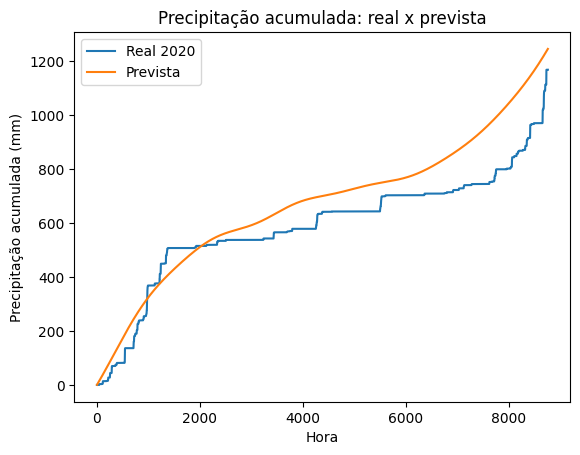

In [177]:
# Complete com seu código
precipitacao_acumulada_prevista = preps_pred.cumsum() # precipitação acumulada prevista pelo modelo


plt.plot(precipitacao_acumulada_2020, label='Real 2020') # Legenda. precipitação acumulada real de 2020
plt.plot(precipitacao_acumulada_prevista, label='Prevista') # Legenda. precipitação acumulada prevista

plt.xlabel('Hora')
plt.ylabel('Precipitação acumulada (mm)')
plt.title('Precipitação acumulada: real x prevista')

plt.legend()
plt.show()



## 3 Regressão Polinomial

Dado $m$ conjuntos de $n$ dados dispostos na matriz $\mathbf{X} \in {\mathbb{R}}^{m\times n+1}$ rotulados por $\mathbf{y} \in {\mathbb{R}}^m$ já definimos anteriormente que o erro será minimizado quando
$$
\newcommand{\mw}{\mathbf w}\mw = (\newcommand{\mX}{\mathbf X} \mX^T \mX)^{-1} \mX^T \newcommand{\my}{\mathbf y} \my
$$

Derivar por um vetor pode parecer desconfortável, mas não há com o que se preocupar. Lembre-se de que aqui apenas usamos notação de matriz para representar convenientemente um sistema de fórmulas lineares. Portanto, derivamos por cada componente do vetor e depois combinamos as derivadas resultantes em um vetor novamente,
$$
\frac{\partial}{\partial w_{k}}\sum_{i=1}^{m}\left(y^{(i)}-\sum_{j=0}^{n}x_{ij}w_{j}\right)^{2}=0
$$

$$
\sum_{i=1}^{m}2\left(y^{(i)}-\sum_{j=1}^{n}x_{ij}w_{j}\right)\left(\frac{\partial}{\partial w_{k}}\left[y^{(i)}-\sum_{j=1}^{n}x_{ij}w_{j}\right]\right)=0
$$

$$
-2\sum_{i=1}^{m}x_{ik}\left(y^{(i)}-\sum_{j=1}^{n}x_{ij}w_{j}\right)=0 \tag{1}
$$

Pode-se reescrever as equações (1) na forma matricial. Por exemplo, para um polinômio de ordem $4$,
\begin{equation}
              \begin{pmatrix}
              m \, \, \, \, \, \, \, & \sum{x^{(i)}}\, \, & \sum{\left(x^{(i)}\right)^2} & \sum{\left(x^{(i)}\right)^3} & \sum{\left(x^{(i)}\right)^4}  \\
              \sum{x^{(i)}}\, \, & \sum{\left(x^{(i)}\right)^2} & \sum{\left(x^{(i)}\right)^3} & \sum{\left(x^{(i)}\right)^4} & \sum{\left(x^{(i)}\right)^5}  \\
              \sum{\left(x^{(i)}\right)^2} & \sum{\left(x^{(i)}\right)^3} & \sum{\left(x^{(i)}\right)^4} & \sum{\left(x^{(i)}\right)^5} & \sum{\left(x^{(i)}\right)^6}  \\
              \sum{\left(x^{(i)}\right)^3} & \sum{\left(x^{(i)}\right)^4} & \sum{\left(x^{(i)}\right)^5} & \sum{\left(x^{(i)}\right)^6} & \sum{\left(x^{(i)}\right)^7}  \\
              \sum{\left(x^{(i)}\right)^4} & \sum{\left(x^{(i)}\right)^5} & \sum{\left(x^{(i)}\right)^6} & \sum{\left(x^{(i)}\right)^7} & \sum{\left(x^{(i)}\right)^8}  \\
              \end{pmatrix}
              \begin{pmatrix}
              w_0 \\
              w_1 \\
              w_2 \\
              w_3 \\
              w_4 \\
              \end{pmatrix}
              =\begin{pmatrix}
              \sum{ y^{(i)}} \\
              \sum{x^{(i)} y^{(i)}} \\
              \sum{\left(x^{(i)}\right)^2 y^{(i)}} \\
              \sum{\left(x^{(i)}\right)^3 y^{(i)}} \\
              \sum{\left(x^{(i)}\right)^4 y^{(i)}} \\
              \end{pmatrix} \tag{2}
\end{equation}

Note que isso é um caso particular de regressão multidimensional.

## Exercício 3.1

Os dados para o exercício foram gerados artificialmente, com a equação básica dada por,
$$
y=0.3x^3-20x^2+5x-4
$$


In [ ]:
x=np.linspace(-50,150,50)
y=0.3*x**3 - 20*x**2 + 5*x - 4 + 5000*np.random.randn(50)
plt.scatter(x, y, color="black")
plt.show()

Recupere os coeficientes de regressão para polinômios de grau 1, 2 e 3.
Para cada um destes, identifique o erro quadrático médio.

Você pode usar numpy para construir a matriz ${\mathbf X}$, a matriz ${\mathbf X}^T{\mathbf X}$ e o vetor ${\mathbf X}^T {\mathbf y}$. Em seguida use ```numpy.linalg.solve``` para resolver o sistema linear.

Vamos no entanto usar
 ```LinearModel``` e a classe ```PolinomialFeatures``` do pacote ```sklearn.preprocessing``` para gerar a base de vetores de variáveis independentes.
Para construir um objeto de *features* de grau ```n```, use a sintaxe ```PolinomialFeatures(degree=n)```.
O objeto pode ser usado para construir a base de variáveis independentes nos pontos do vetor unidimensional ```x``` com a chamada ao método ```fit_transform(x.reshape(-1,1))```. A matriz de variáveis independentes resultante pode ser usada diretamente por um objeto ```LinearModel``` na chamada ao método ```fit```.

O valor do resíduo quadrático médio pode ser calculado diretamente por ```sklearn``` usando a função  ```sklearn.metrics.mena_squared_error```. Se ```y``` contém os valores reais da variável e ```y_previsto``` os valores previstos, então ```mean_squared_error(y, y_previsto)``` retorna o erro quadrático médio.

In [179]:
# Complete com seu código
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error

# Testa graus 1, 2 e 3
for i in [1, 2, 3]:
    
    poly = PolynomialFeatures(degree=i) # Cria as variáveis polinomiais   
    X = poly.fit_transform(x.reshape(-1,1)) # Gera a matriz X
    modelo = LinearRegression() # Cria o modelo de regressão  
    modelo.fit(X, y)  # Treina o modelo
    y_pred = modelo.predict(X) # Calcula os valores previstos
    mse = mean_squared_error(y, y_pred) # Calcula o erro quadrático médio

    print(f"\nGrau {i}")

    print("Coeficientes:", modelo.coef_)
    print("Intercepto:", modelo.intercept_)
    print("MSE:", mse)


Grau 1
Coeficientes: [0.         0.01551358]
Intercepto: 4.950924356109552
MSE: 24.84317170291906

Grau 2
Coeficientes: [ 0.         -0.03966524  0.00550618]
Intercepto: 4.94364369231449
MSE: 24.800924428749557

Grau 3
Coeficientes: [ 0.00000000e+00 -3.87517913e-02  4.04285227e-03  8.89512306e-05]
Intercepto: 4.966817875481627
MSE: 24.80003504928058


## 4. Regularização


A ideia por trás da regularização é ter valores menores dos parâmetros, levando a hipóteses mais simples, mais suaves e com menos tendência ao overfitting.

$$
\newcommand{\om}{\mathbf w} \hat{\mathbf w} = \arg \min_{\mathbf w} \frac{1}{m} \sum_{i=1}^n \textbf{L}\left(y^{(i)}, h_\om\left(\mathbf x^{(i)}\right)\right) + \lambda \textbf{R}(\om)
$$

O termo de regularização $\textbf{R}(\newcommand{\om}{\mathbf w} \om)$ penaliza valores de $\om$ que resultam em modelos mais complexos e, portanto, com variância maior. O hiperparâmetro de regularização $\lambda$ determina o grau de regularização a ser aplicado e geralmente é determinado por meio de validação cruzada (*cross validation*).

As técnicas mais conhecidas de regularização por penalidade são Lasso e Ridge (conforme equações abaixo).
$$
\textbf{R}_{L^2}(\om) =
||\om||_2^2 = \om^T \om  = \sum_{k=1}^n \om_k^2
$$
veja que $w_0$ não faz parte da regularização.

Já a regressão linear de mínimos quadrados em conjunto com a norma L1 é denominada Lasso (*Least Absolute Shrinkage and Selection Operator*), ou simplesmente  L1. Em contraste com a norma L2, a norma L1 incentiva os valores de $w_i$ a serem exatamente zero em dimensões menos informativas (coeficientes menos importantes), reduzindo assim a complexidade do modelo e diminuindo o número de feaures.
$$
\textbf{R}_{L^1}(\om) = \sum_{k=1}^n |w_k|
$$
Portanto, Lasso funciona bem para *seleção de features*, caso existam em grande número.

 ![](https://drive.google.com/uc?export=view&id=1CWvDjEaGkXsqYUWFrgpmFOYXgkWEiPB5)



## Exercício 4.1

No exercício anterior, você testou polinômios de até grau 3.
De fato, era sabido pelo enunciado que o grau máximo relevante era esse. Mas essa informação na prática é desconhecida.


Repita o processo agora com um polinômio de grau 12(!)

Preveja o resultado usando o método ```predict``` do objeto ```LinearModel``` (lembre-se que você deve usar a projeção da série ```x``` no vetor de Features).

Mostre a sobreposição entre os dados de treinamento e o resultado do modelo.
Se você colocar a previsão na variável ```ypredict12```, a plotagem desejada é obtida com:


```
plt.plot(x, ypredict12, color="red")
plt.scatter(x, y, color="black")
plt.show()
```

Mostre o coeficiente de 3 grau (índice 3) do modelo obtido. Compare-o com o da curva original.

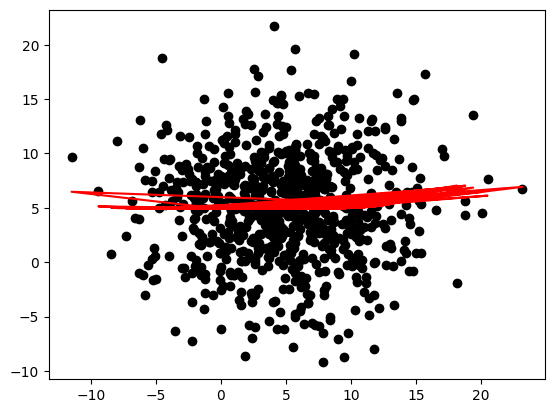

In [ ]:
# Complete com seu código
poly12 = PolynomialFeatures(degree=12) # Cria as features polinomiais de grau 12

# Monta a matriz X
X12 = poly12.fit_transform(x.reshape(-1,1))

modelo12 = LinearRegression() # Cria o modelo
modelo12.fit(X12, y) # Treina o modelo
ypredict12 = modelo12.predict(X12) # Calcula os valores previstos


plt.plot(x, ypredict12, color="red")
plt.scatter(x, y, color="black")
plt.show()

Embora *pontualmente* a curva possa acompanhar melhor os pontos, o modelo está claramente irregular, sintoma de *overfitting*.
Em paricular, a menos que você tenha tido uma sorte extraordinária, o coeficiente de grau 3 deve ter um valor completamente diferente do esperado.

Isso acontece por que a interpolação está sendo dominada por features de grau mais elevado.

Vamos eliminar este fenômeno com uma regularização do tipo Lasso.
A penalização Lasso deve penalizar features inseridas por overfitting, mantendo apenas as realmente necessárias para o modelo.

Para tanto use a classe ```Lasso``` do pacote ```linear_model```.
O seu construtor recebe um parâmetro ```alpha```, correspondente ao peso da penalização.

O seu valor padrão é 1.0. Pode usar este mesmo valor.

O objeto ```Lasso``` funciona da mesma maneira que o ```LinearRegression```.

Repita o trabalho do item anterior


c:\Users\ander\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 9.908041e+03, tolerance: 1.988e+00
  model = cd_fast.enet_coordinate_descent(


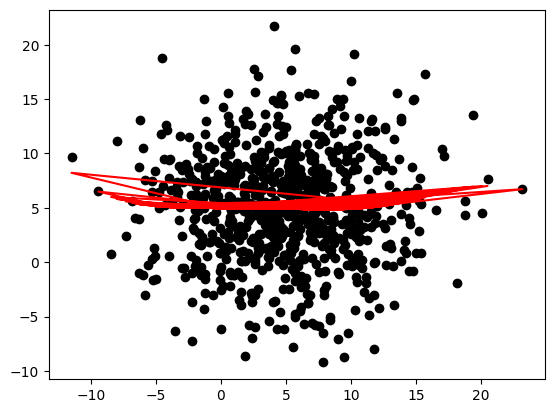

Coeficiente grau 3 = -0.000873954568085787


In [ ]:
# Complete com seu código
from sklearn.linear_model import Lasso


modelo_lasso = Lasso(alpha=1.0) # Cria o modelo Lasso
modelo_lasso.fit(X12, y) # Treina o modelo

ypredict12 = modelo_lasso.predict(X12) # Calcula os valores previstos


plt.plot(x, ypredict12, color="red")
plt.scatter(x, y, color="black")
plt.show()

# Coeficiente do termo x³
print("Coeficiente grau 3 =", modelo_lasso.coef_[3])